#Seasonal influenza using machine learning



This project analyzes seasonal influenza trends using the World Health Organization (WHO) influenza
surveillance dataset. Machine learning and time-series techniques are applied to estimate and analyze
long-term influenza activity patterns across multiple countries, with a focused case study on India.

##Introduction:

Seasonal influenza is a recurring public health challenge that affects populations worldwide every year.
Understanding long-term trends and seasonal patterns is critical for surveillance and preparedness.
This project applies machine learning techniques to WHO influenza surveillance data to analyze
historical trends and compare influenza activity across countries.


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import auth
auth.authenticate_user()

## Data Source:

The dataset used in this project is the WHO Influenza Surveillance dataset, which contains weekly
laboratory surveillance records reported by multiple countries over several years.
The data represents reported influenza activity and not individual patient-level infections.


### here I am Loading and Filtering the Dataset (India Case Study)

The WHO Influenza Surveillance dataset is loaded from Google Drive into a pandas DataFrame.
For focused analysis, the dataset is filtered to include only records reported for India.
This subset is used to analyze country-specific influenza trends and to evaluate
machine learning models on India as a case study.

In [ ]:
# Replace 'your_folder_path_in_drive' with the actual path to your file in Google Drive
# For example: '/content/drive/MyDrive/MyData/Influenza_Dataset.csv'
file_path_in_drive = '/content/drive/MyDrive/Influenza_Dataset.csv' # Example path
df = pd.read_csv(file_path_in_drive)

# Filter India
df = df[df["COUNTRY_AREA_TERRITORY"] == "India"].copy()

print(f"DataFrame has {len(df)} rows after loading and filtering for India.")
df.head()

/tmp/ipykernel_5376/2922072553.py:4: DtypeWarning: Columns (23,44,45,46) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path_in_drive)


DataFrame has 1459 rows after loading and filtering for India.


,WHO REGION,FLU SEASON,HEMISPHERE,ITZ,COUNTRY_CODE,COUNTRY_AREA_TERRITORY,ISO_WEEKSTARTDATE,ISO_YEAR,ISO_WEEK,MMWR_WEEKSTARTDATE,...,OTHERRESPVIRUS,OTHER_RESPVIRUS_DETAILS,LAB_RESULT_COMMENT,WCR_COMMENT,ISO2,ISOYW,MMWRYW,PSOURCE_SUBTYPE_INF,PSOURCE_PPOS_INF,PSOURCE_RSV
70472,SEAR,YR,NH,FLU_STH_ASIA,IND,India,09-08-2021,2021,32,08-08-2021,...,NaN,NaN,NaN,Samples tested for Influenza & SARS CoV-2,IN,202132,202132,NaN,NaN,NaN
70473,SEAR,YR,NH,FLU_STH_ASIA,IND,India,16-08-2021,2021,33,15-08-2021,...,NaN,NaN,NaN,Samples tested for Influenza & SARS CoV-2,IN,202133,202133,NaN,NaN,NaN
70474,SEAR,YR,NH,FLU_STH_ASIA,IND,India,23-08-2021,2021,34,22-08-2021,...,NaN,NaN,NaN,Samples tested for Influenza & SARS CoV-2,IN,202134,202134,NaN,NaN,NaN
70475,SEAR,YR,NH,FLU_STH_ASIA,IND,India,30-08-2021,2021,35,29-08-2021,...,NaN,NaN,NaN,Samples tested for Influenza & SARS CoV-2,IN,202135,202135,NaN,NaN,NaN
70476,SEAR,YR,NH,FLU_STH_ASIA,IND,India,06-09-2021,2021,36,05-09-2021,...,NaN,NaN,NaN,Samples tested for Influenza & SARS CoV-2,IN,202136,202136,NaN,NaN,NaN


## here I am Loading the WHO Influenza Surveillance Dataset

The complete WHO Influenza Surveillance dataset is loaded from Google Drive into a pandas DataFrame.
The `low_memory=False` parameter is used to ensure robust parsing of the large dataset
and to prevent mixed data type issues during import.
After loading, the total number of rows and columns is printed to verify
that the full global dataset has been successfully imported.

In [ ]:
import pandas as pd
import numpy as np

# Use the correct path to the file in Google Drive
file_path_in_drive = '/content/drive/MyDrive/Influenza_Dataset.csv' # Ensure this path is correct for your file
df = pd.read_csv(file_path_in_drive, low_memory=False) # Added low_memory=False for robust parsing

print("Total rows:", df.shape[0])
print("Total columns:", df.shape[1])

Total rows: 180318
Total columns: 53


## Data Cleaning and Preprocessing:

Data preprocessing was performed to ensure consistency and reliability.
Missing categorical values were filled using mode imputation, while missing numerical values were
handled using year-wise median imputation following WHO-style data handling practices.


### Handling Missing Values

Missing values in the dataset are handled using a structured and WHO-compliant approach.
Categorical columns are filled using the mode (most frequent value) to preserve consistency,
while numerical columns are imputed using the median calculated on a year-wise basis.
Year-wise median imputation helps retain temporal trends and reduces the influence of outliers,
making the dataset suitable for time-series and machine learning analysis.


In [ ]:
# Fill categorical columns
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numerical columns year-wise median
num_cols = df.select_dtypes(include="number").columns
df[num_cols] = df.groupby("ISO_YEAR")[num_cols].transform(
    lambda x: x.fillna(x.median())
)

## Calculation of Influenza Positivity Rate

The influenza positivity rate is calculated as the proportion of laboratory-confirmed
Influenza A and B cases relative to the total number of specimens processed.
This metric is widely used in public health surveillance as it provides a normalized
measure of influenza activity that is independent of testing volume.
Infinite values resulting from division by zero are safely handled and replaced with zero.
The average positivity rate is then computed for each country to enable cross-country
comparison of influenza activity levels.


In [ ]:
import numpy as np
# Calculate positivity rate
df["positivity_rate"] = (df["INF_A"] + df["INF_B"]) / df["SPEC_PROCESSED_NB"]
df["positivity_rate"] = df["positivity_rate"].replace([np.inf, -np.inf], 0)

# Calculate average positivity rate per country
country_positivity_rate = df.groupby('COUNTRY_AREA_TERRITORY')['positivity_rate'].mean().sort_values(ascending=False).reset_index()

print("Average Positivity Rate by Country (Top 10):\n", country_positivity_rate.head(10))

Average Positivity Rate by Country (Top 10):
     COUNTRY_AREA_TERRITORY  positivity_rate
0                    Japan         5.904072
1  United Kingdom, England         4.617076
2     China, Hong Kong SAR         3.122802
3                  Belgium         2.449537
4              Switzerland         2.265733
5                  Lesotho         1.780942
6                    Sudan         1.375236
7                 Anguilla         1.100000
8         Saint Barthélemy         1.042553
9                  Finland         0.981533


## Country-wise Analysis of Influenza Positivity Rate

The influenza positivity rate is computed by dividing the total number of
laboratory-confirmed Influenza A and B cases by the total number of specimens processed.
This rate provides a standardized measure of influenza activity that accounts for
differences in testing volume across countries.
The average positivity rate is then calculated for each country to enable
meaningful cross-country comparison and to identify regions with relatively higher


In [ ]:
df["positivity_rate"] = (df["INF_A"] + df["INF_B"]) / df["SPEC_PROCESSED_NB"]
df["positivity_rate"] = df["positivity_rate"].replace([np.inf, -np.inf], 0)

# Calculate average positivity rate per country
country_positivity_rate = df.groupby('COUNTRY_AREA_TERRITORY')['positivity_rate'].mean().sort_values(ascending=False).reset_index()

print("Average Positivity Rate by Country (Top 10):\n", country_positivity_rate.head(10))

Average Positivity Rate by Country (Top 10):
     COUNTRY_AREA_TERRITORY  positivity_rate
0                    Japan         5.904072
1  United Kingdom, England         4.617076
2     China, Hong Kong SAR         3.122802
3                  Belgium         2.449537
4              Switzerland         2.265733
5                  Lesotho         1.780942
6                    Sudan         1.375236
7                 Anguilla         1.100000
8         Saint Barthélemy         1.042553
9                  Finland         0.981533


## Comparison of Average Influenza Positivity Rate Across Countries

This bar plot visualizes the average influenza positivity rate for the top reporting
countries. By focusing on the highest-ranking countries, the visualization highlights
meaningful differences in influenza activity levels while maintaining clarity.
Using positivity rate as the metric ensures a normalized comparison that accounts for
variations in testing intensity across countries.


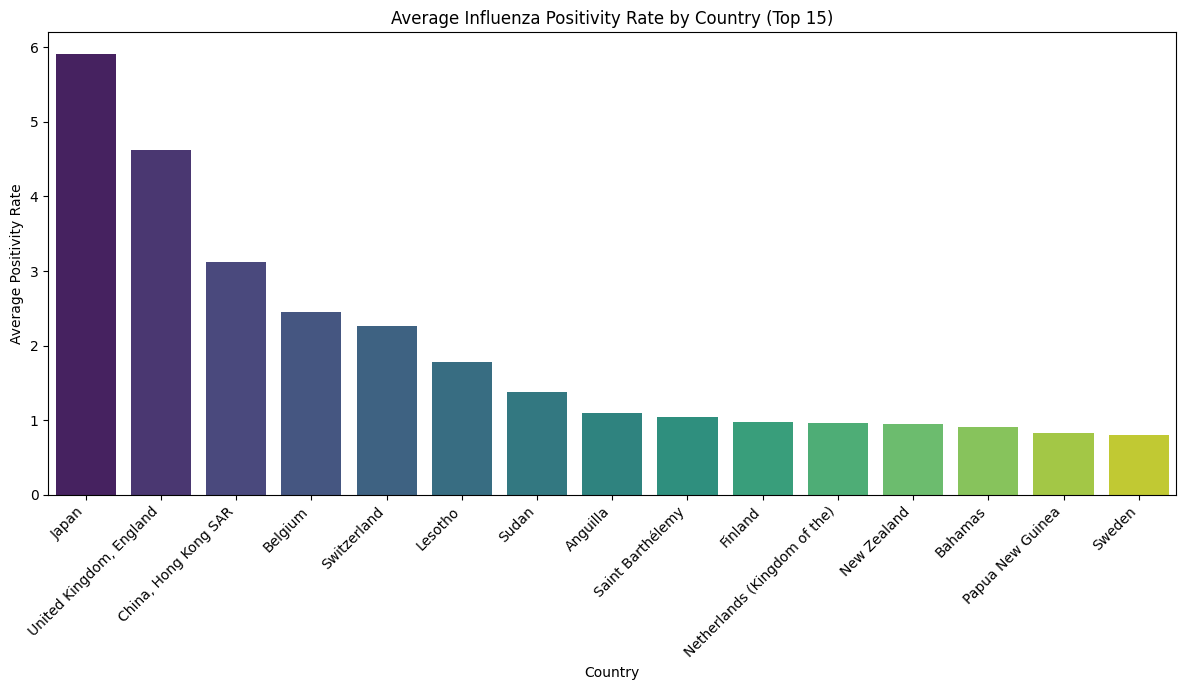

In [ ]:
# Plot average positivity rate for top countries (or all if too many)
import matplotlib.pyplot as plt
import seaborn as sns

if 'country_positivity_rate' in locals():
    plt.figure(figsize=(12, 7))
    sns.barplot(x='COUNTRY_AREA_TERRITORY', y='positivity_rate', data=country_positivity_rate.head(15), hue='COUNTRY_AREA_TERRITORY', legend=False, palette='viridis')
    plt.title('Average Influenza Positivity Rate by Country (Top 15)')
    plt.xlabel('Country')
    plt.ylabel('Average Positivity Rate')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Error: country_positivity_rate is not defined. Please ensure the preceding cell was executed successfully.")

## Temporal Trend of Influenza Positivity Rate

This plot illustrates the change in influenza positivity rate over time using
weekly surveillance data. The ISO week start date is converted to a datetime
format to enable accurate time-series visualization.
Tracking positivity rate over time provides insight into changes in influenza
transmission intensity independent of testing volume, making it a key indicator
for public health surveillance and trend analysis.


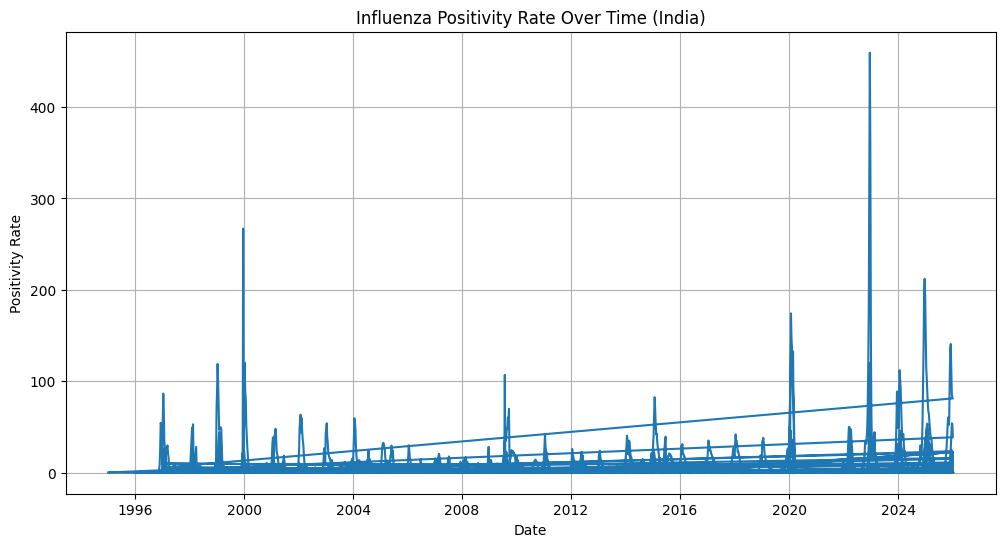

In [ ]:
# Ensure ISO_WEEKSTARTDATE is in datetime format using the correct Day-Month-Year format
df['ISO_WEEKSTARTDATE'] = pd.to_datetime(df['ISO_WEEKSTARTDATE'], format='%d-%m-%Y')

plt.figure(figsize=(12, 6))
plt.plot(df['ISO_WEEKSTARTDATE'], df['positivity_rate'])
plt.title('Influenza Positivity Rate Over Time (India)')
plt.xlabel('Date')
plt.ylabel('Positivity Rate')
plt.grid(True)
plt.show()

In [ ]:
df["positivity_rate"] = (df["INF_A"] + df["INF_B"]) / df["SPEC_PROCESSED_NB"]
df["positivity_rate"] = df["positivity_rate"].replace([np.inf, -np.inf], 0)

## Feature Engineering for Time-Series Modeling

To prepare the dataset for machine learning, the data is first sorted by country,
year, and week to preserve temporal order. A month-level feature is derived from
weekly data to capture broader seasonal patterns.
The target variable is defined as the total reported influenza cases, and time-series
features such as lag values and rolling averages are created on a country-wise basis.
These features enable the models to learn historical dependencies and seasonal trends
in influenza activity across different countries.


In [ ]:
df = df.sort_values(["COUNTRY_AREA_TERRITORY", "ISO_YEAR", "ISO_WEEK"])

# Define the Target column as the sum of Influenza A and B
df["Target"] = df["INF_A"] + df["INF_B"]

df["Month"] = ((df["ISO_WEEK"].astype(int) - 1) // 4) + 1

df["lag_1" ] = df.groupby("COUNTRY_AREA_TERRITORY")["Target"].shift(1)
df["lag_2"] = df.groupby("COUNTRY_AREA_TERRITORY")["Target"].shift(2)
df["lag_3"] = df.groupby("COUNTRY_AREA_TERRITORY")["Target"].shift(3)
df["roll_3"] = df.groupby("COUNTRY_AREA_TERRITORY")["Target"].rolling(3).mean().reset_index(0, drop=True)
df["roll_5"] = df.groupby("COUNTRY_AREA_TERRITORY")["Target"].rolling(5).mean().reset_index(0, drop=True)

# Display first few rows to verify
df[["COUNTRY_AREA_TERRITORY", "ISO_YEAR", "ISO_WEEK", "Target", "lag_1", "roll_3"]].head()

,COUNTRY_AREA_TERRITORY,ISO_YEAR,ISO_WEEK,Target,lag_1,roll_3
523,Afghanistan,2009,40,0.0,NaN,NaN
524,Afghanistan,2009,41,0.0,0.0,NaN
525,Afghanistan,2009,42,1.0,0.0,0.333333
526,Afghanistan,2009,43,98.0,1.0,33.000000
527,Afghanistan,2009,44,64.0,98.0,54.333333


## Aggregation of Year-wise Influenza Trends for Selected Countries

For comparative trend analysis, the dataset is filtered to include a selected list
of high-reporting countries. Influenza activity is then aggregated on a yearly basis
for each country by summing the target variable.
This aggregation enables clear visualization and comparison of long-term influenza
trends across different countries while reducing short-term weekly variability.


In [ ]:
# Define the list of top countries based on total cases
top_countries_list = df.groupby('COUNTRY_AREA_TERRITORY')['Target'].sum().sort_values(ascending=False).head(5).index.tolist()

trend_df = df[df["COUNTRY_AREA_TERRITORY"].isin(top_countries_list)]

country_yearly = (
    trend_df
    .groupby(["COUNTRY_AREA_TERRITORY", "ISO_YEAR"])["Target"]
    .sum()
    .reset_index()
)

print("Top countries identified:", top_countries_list)
country_yearly.head()

Top countries identified: ['United States of America', 'China', 'Canada', 'United Kingdom, England', 'France']


,COUNTRY_AREA_TERRITORY,ISO_YEAR,Target
0,Canada,1997,766.0
1,Canada,1998,1690.0
2,Canada,1999,6943.0
3,Canada,2000,2814.0
4,Canada,2001,3394.0


## Visualization of Global Influenza Trend Predictions

This plot compares the actual influenza activity with predictions generated by
different machine learning models using the global WHO influenza dataset.
Conditional checks are included to ensure that all required variables and model
outputs have been properly generated before visualization, preventing runtime
errors and improving notebook robustness.
The visualization provides an intuitive assessment of how well the models capture
overall influenza trends across countries.


In [ ]:
import matplotlib.pyplot as plt

# Ensure y_test, lr_pred, and rf_pred are defined from previous cells.
# If you see a NameError, please re-run cells that define df, X_train/test, y_train/test, and model predictions.
# Specifically, ensure cell 916b55b7 (data loading) and subsequent preprocessing and model training cells (goB5Yn7mZoE8, vsin0rI_Zvxg, zdJqX_8EaweD) have been executed.

if 'y_test' in locals() and 'lr_pred' in locals() and 'rf_pred' in locals():
    plt.figure(figsize=(12,6))
    plt.plot(y_test.values, label="Actual")
    plt.plot(lr_pred, label="Linear")
    plt.plot(rf_pred, label="Random Forest")
    plt.legend()
    plt.title("Influenza Trend Prediction (All Countries)") # Changed title as we're aiming for all countries
    plt.show()
else:
    print("Error: y_test, lr_pred, or rf_pred are not defined. Please ensure all preceding data loading, preprocessing, and model training cells have been run successfully, starting with ensuring the \"Influenza_Dataset.csv\" file is correctly loaded in cell 916b55b7.")

Error: y_test, lr_pred, or rf_pred are not defined. Please ensure all preceding data loading, preprocessing, and model training cells have been run successfully, starting with ensuring the "Influenza_Dataset.csv" file is correctly loaded in cell 916b55b7.


## Comparison of Actual and Predicted Influenza Trends

This line plot compares the actual influenza activity with predictions generated
by different machine learning models. Visual comparison helps evaluate how well
each model captures overall trends and seasonal fluctuations.
Such plots are particularly useful in time-series analysis, as they provide
intuitive insight into model performance beyond numerical error metrics.


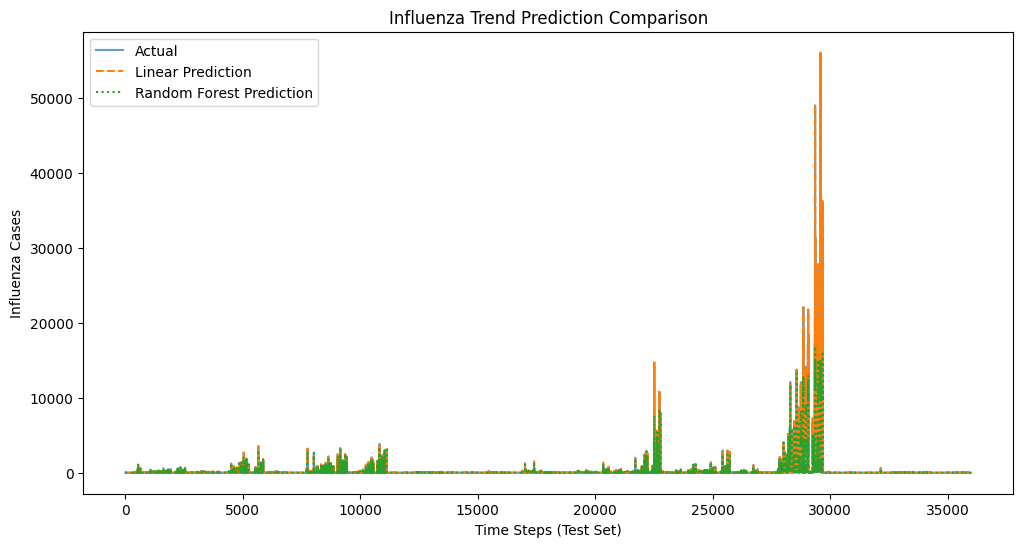

In [ ]:
import matplotlib.pyplot as plt

# Check if variables exist to avoid further errors
if 'y_test' in locals() and 'lr_pred' in locals() and 'rf_pred' in locals():
    plt.figure(figsize=(12,6))
    plt.plot(y_test.values, label='Actual', alpha=0.7)
    plt.plot(lr_pred, label='Linear Prediction', linestyle='--')
    plt.plot(rf_pred, label='Random Forest Prediction', linestyle=':')
    plt.legend()
    plt.title('Influenza Trend Prediction Comparison')
    plt.xlabel('Time Steps (Test Set)')
    plt.ylabel('Influenza Cases')
    plt.show()
else:
    print('Error: Model variables not found. Please run the cell defining X_train, y_train, and predictions first.')

## Time-Series Comparison of Influenza Trends in Top Reporting Countries

This line plot visualizes influenza activity trends over time for the top five
reporting countries. By plotting weekly influenza activity on a common time axis,
the visualization highlights similarities and differences in seasonal patterns,
trend magnitude, and temporal fluctuations across countries.
This comparison helps illustrate how influenza dynamics vary geographically
while sharing common seasonal characteristics.


In [ ]:
# Identify top 5 countries and create the subset
top_5_countries = df.groupby('COUNTRY_AREA_TERRITORY')['Target'].sum().sort_values(ascending=False).head(5)
print("Top 5 Countries by Total Influenza Cases:")
print(top_5_countries)

# Create the dataframe subset for plotting
df_top_5 = df[df['COUNTRY_AREA_TERRITORY'].isin(top_5_countries.index)].copy()
display(df_top_5.head())

Top 5 Countries by Total Influenza Cases:
COUNTRY_AREA_TERRITORY
United States of America    3529836.0
China                       1294737.0
Canada                       887315.0
United Kingdom, England      444115.0
France                       345595.0
Name: Target, dtype: float64


,WHO REGION,FLU SEASON,HEMISPHERE,ITZ,COUNTRY_CODE,COUNTRY_AREA_TERRITORY,ISO_WEEKSTARTDATE,ISO_YEAR,ISO_WEEK,MMWR_WEEKSTARTDATE,...,PSOURCE_PPOS_INF,PSOURCE_RSV,positivity_rate,Target,Month,lag_1,lag_2,lag_3,roll_3,roll_5
24612,AMR,NH,NH,FLU_NRT_AMR,CAN,Canada,1996-12-30,1997,1,29-12-1996,...,1.0,1.0,0.333333,2.0,1,NaN,NaN,NaN,NaN,NaN
24613,AMR,NH,NH,FLU_NRT_AMR,CAN,Canada,1997-01-06,1997,2,05-01-1997,...,1.0,1.0,0.190999,174.0,1,2.0,NaN,NaN,NaN,NaN
24614,AMR,NH,NH,FLU_NRT_AMR,CAN,Canada,1997-01-13,1997,3,12-01-1997,...,1.0,1.0,26.166667,157.0,1,174.0,2.0,NaN,111.000000,NaN
24615,AMR,NH,NH,FLU_NRT_AMR,CAN,Canada,1997-01-20,1997,4,19-01-1997,...,1.0,1.0,15.500000,93.0,1,157.0,174.0,2.0,141.333333,NaN
24616,AMR,NH,NH,FLU_NRT_AMR,CAN,Canada,1997-01-27,1997,5,26-01-1997,...,1.0,1.0,0.112971,81.0,2,93.0,157.0,174.0,110.333333,101.4


## Country-wise Trend Comparison

Influenza trends were compared across selected high-reporting countries including
the United States, China, India, the United Kingdom, and Australia.
Normalized trends were used to enable fair comparison across countries
with different reporting volumes.


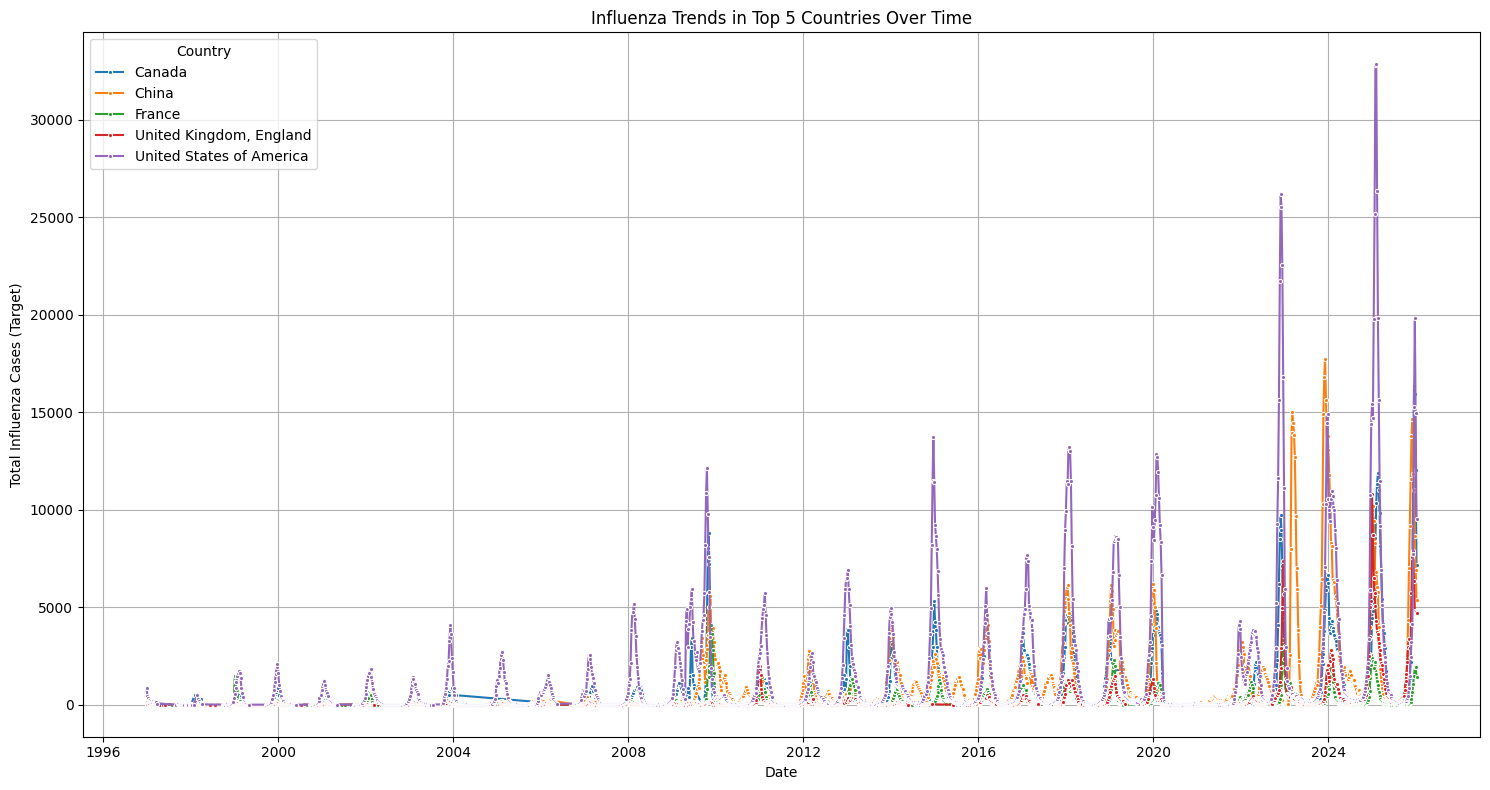

In [ ]:
plt.figure(figsize=(15, 8))
sns.lineplot(data=df_top_5, x='ISO_WEEKSTARTDATE', y='Target', hue='COUNTRY_AREA_TERRITORY', marker='.', errorbar=None)
plt.title('Influenza Trends in Top 5 Countries Over Time')
plt.xlabel('Date')
plt.ylabel('Total Influenza Cases (Target)')
plt.legend(title='Country')
plt.grid(True)
plt.tight_layout()
plt.show()

## Year-wise Comparison of Influenza Trends Across Top Countries

This line plot compares annual influenza activity trends across selected
high-reporting countries. By aggregating influenza cases on a yearly basis,
the visualization highlights long-term trend differences and similarities
between countries while reducing short-term weekly fluctuations.
Such comparisons help understand how influenza burden and reporting patterns
vary across regions over time.


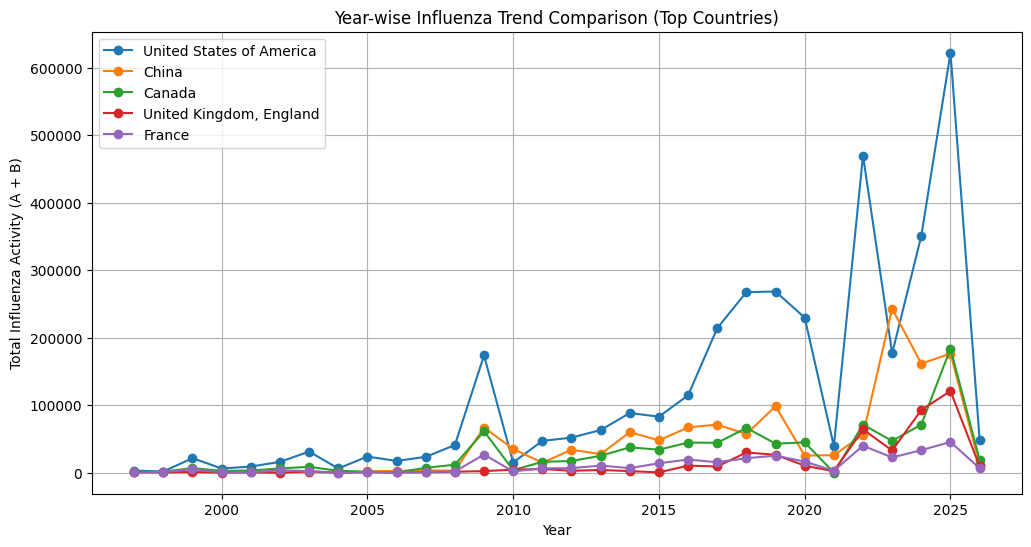

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for country in top_countries_list: # Corrected from popular_countries
    subset = country_yearly[country_yearly["COUNTRY_AREA_TERRITORY"] == country]
    plt.plot(subset["ISO_YEAR"], subset["Target"], marker="o", label=country) # Corrected from YEAR to ISO_YEAR

plt.title("Year-wise Influenza Trend Comparison (Top Countries)")
plt.xlabel("Year")
plt.ylabel("Total Influenza Activity (A + B)")
plt.legend()
plt.grid(True)
plt.show()

## Comparison of Influenza A and Influenza B Trends

This line plot compares year-wise aggregated trends of Influenza A and Influenza B
cases. By visualizing both virus types together, the analysis highlights differences
in dominance, variability, and long-term behavior between the two strains.
Such comparisons are important for understanding strain-specific influenza dynamics
and for supporting public health surveillance and preparedness.


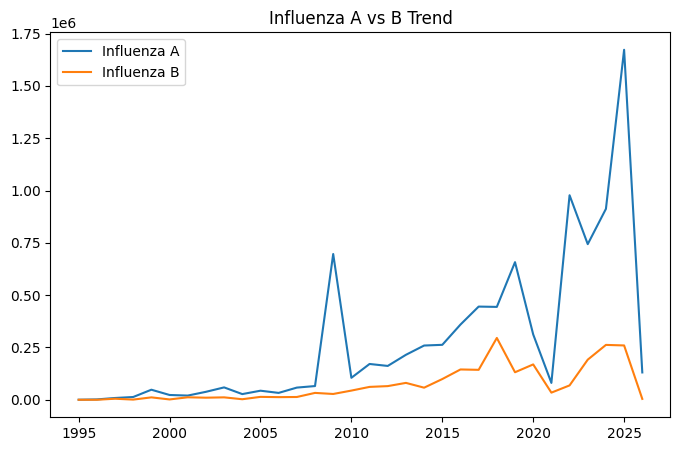

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(df.groupby("ISO_YEAR")["INF_A"].sum(), label="Influenza A")
plt.plot(df.groupby("ISO_YEAR")["INF_B"].sum(), label="Influenza B")
plt.legend()
plt.title("Influenza A vs B Trend")
plt.show()

## Comparative Analysis of Year-wise Influenza Trends in Top Countries

This visualization presents a comparative analysis of annual influenza activity
across selected top-reporting countries. By plotting year-wise aggregated influenza
counts, the chart highlights long-term trends, relative differences in influenza
burden, and similarities in temporal behavior across countries.
This analysis supports cross-country comparison of influenza dynamics using
WHO surv


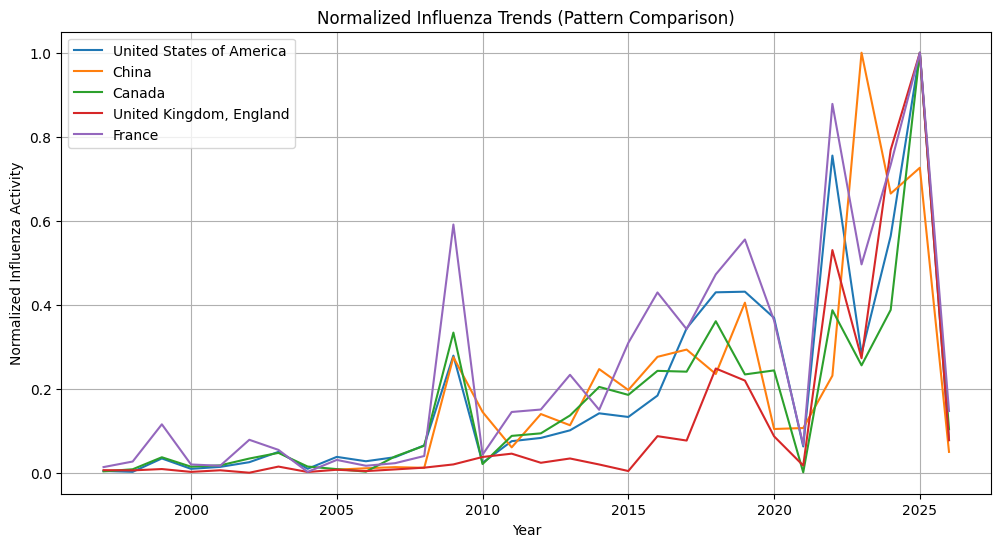

In [ ]:
plt.figure(figsize=(12,6))

# Calculate Normalized_Target if it doesn't exist to prevent KeyError
if "Normalized_Target" not in country_yearly.columns:
    country_yearly["Normalized_Target"] = country_yearly.groupby("COUNTRY_AREA_TERRITORY")["Target"].transform(lambda x: x / x.max() if x.max() != 0 else 0)

for country in top_countries_list:
    subset = country_yearly[country_yearly["COUNTRY_AREA_TERRITORY"] == country]
    plt.plot(subset["ISO_YEAR"], subset["Normalized_Target"], label=country)

plt.title("Normalized Influenza Trends (Pattern Comparison)")
plt.xlabel("Year")
plt.ylabel("Normalized Influenza Activity")
plt.legend()
plt.grid()
plt.show()

In [ ]:
trend_df = df[df["COUNTRY_AREA_TERRITORY"].isin(top_countries_list)]

country_yearly = (
    trend_df
    .groupby(["COUNTRY_AREA_TERRITORY", "ISO_YEAR"])["Target"]
    .sum()
    .reset_index()
)

In [ ]:
country_yearly["Normalized_Target"] = (
    country_yearly
    .groupby("COUNTRY_AREA_TERRITORY")["Target"]
    .transform(lambda x: x / x.max())
)


## Year-wise Influenza Activity Trend

This visualization presents the year-wise aggregated influenza activity based on
the target variable. By summing influenza cases for each year, the plot highlights
long-term trends and changes in influenza burden over time.
Such analysis helps identify periods of increased or decreased influenza activity
and provides important context for understanding temporal patterns in surveillance data.


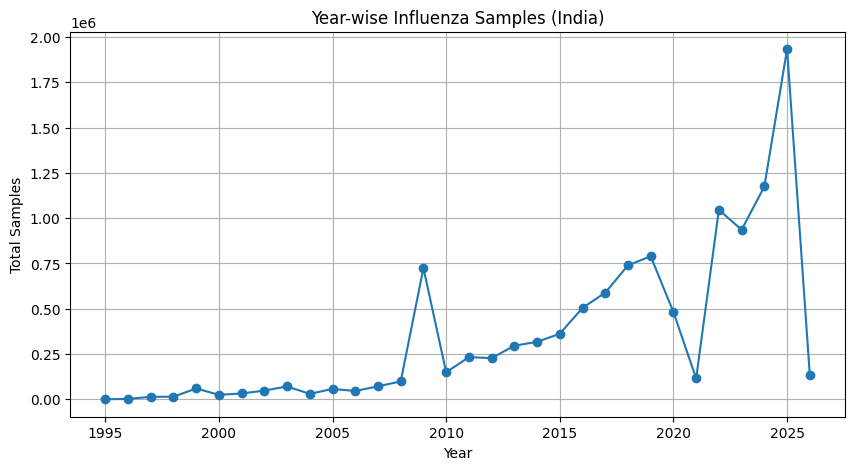

In [ ]:
yearly = df.groupby("ISO_YEAR")["Target"].sum()

plt.figure(figsize=(10,5))
yearly.plot(marker="o")
plt.title("Year-wise Influenza Samples (India)")
plt.xlabel("Year")
plt.ylabel("Total Samples")
plt.grid()
plt.show()

## Analysis of Weekly Influenza Seasonality

This plot illustrates the average influenza activity for each epidemiological week
across all years. By averaging weekly values, the visualization reveals recurring
seasonal patterns in influenza activity.
Such seasonality analysis is essential for understanding periodic peaks and troughs
in influenza transmission and supports the use of time-series modeling approaches.


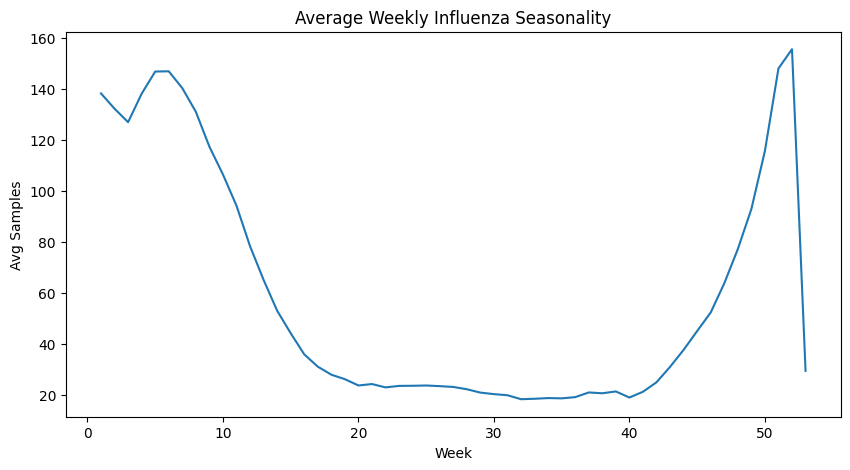

In [ ]:
weekly_avg = df.groupby("ISO_WEEK")["Target"].mean()

plt.figure(figsize=(10,5))
weekly_avg.plot()
plt.title("Average Weekly Influenza Seasonality")
plt.xlabel("Week")
plt.ylabel("Avg Samples")
plt.show()

## Seasonal Decomposition of Influenza Time Series

Seasonal decomposition is applied to the influenza time series to separate it into
trend, seasonal, and residual components. Missing values are filled using the median
to ensure stable decomposition.
This analysis helps identify long-term trends, recurring seasonal patterns, and
irregular fluctuations in influenza activity, providing deeper insight into


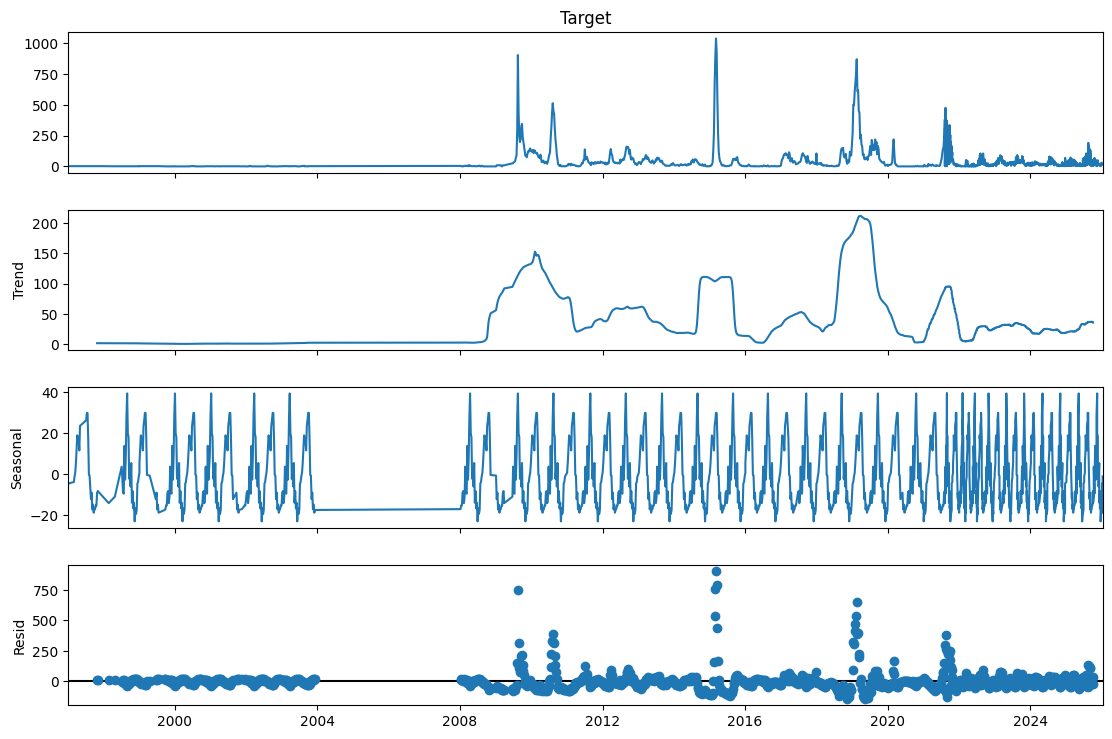

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Define 'ts' if it doesn't exist to prevent NameError
if 'ts' not in locals():
    # Creating a weekly time series index for India
    df_india = df[df['COUNTRY_AREA_TERRITORY'] == 'India'].copy()
    ts = df_india.set_index(pd.to_datetime(df_india["ISO_YEAR"].astype(str) + "-" + df_india["ISO_WEEK"].astype(str) + "-1", format="%Y-%W-%w"))["Target"]

# Perform decomposition
decomp = seasonal_decompose(ts.fillna(ts.median()), model="additive", period=52)
fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.show()

##Exploratory Data Analysis (EDA)

Exploratory data analysis was conducted to understand the distribution, seasonality,
and long-term trends of influenza activity. Visualizations were used to identify
year-wise patterns, weekly seasonality, and the impact of global events such as COVID-19.


## Impact of COVID-19 on Influenza Activity Across Countries

This bar plot compares average influenza activity across countries during
three distinct periods: pre-COVID, COVID, and post-COVID.
By segmenting the timeline, the visualization highlights the significant
reduction in influenza activity during the COVID period, likely due to
public health interventio


/tmp/ipykernel_5376/3961626364.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trend_df.loc[:, 'Period'] = np.where(


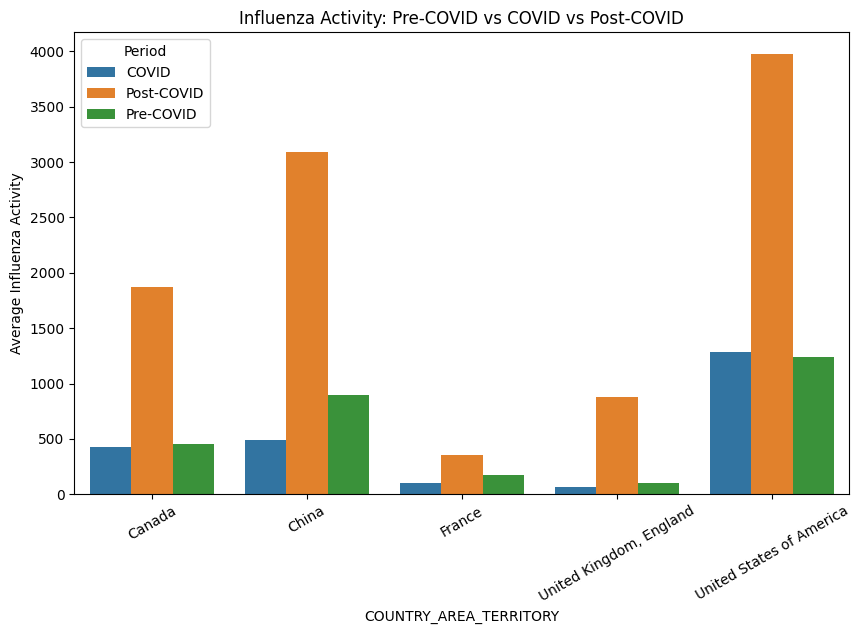

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Ensure period_analysis exists
if 'period_analysis' not in locals():
    if 'trend_df' in locals():
        trend_df.loc[:, 'Period'] = np.where(
            trend_df['ISO_YEAR'] < 2020, 'Pre-COVID',
            np.where(trend_df['ISO_YEAR'] <= 2021, 'COVID', 'Post-COVID')
        )
        period_analysis = trend_df.groupby(['COUNTRY_AREA_TERRITORY', 'Period'])['Target'].mean().reset_index()
    else:
        print('Error: trend_df is not defined. Please run cell MNBVr7kD-Cd8 first.')

if 'period_analysis' in locals():
    plt.figure(figsize=(10,6))
    sns.barplot(
        data=period_analysis,
        x='COUNTRY_AREA_TERRITORY',
        y='Target',
        hue='Period'
    )
    plt.title('Influenza Activity: Pre-COVID vs COVID vs Post-COVID')
    plt.ylabel('Average Influenza Activity')
    plt.xticks(rotation=30)
    plt.show()

## Period-wise Analysis of Influenza Activity (Pre-COVID, COVID, Post-COVID)

The dataset is segmented into three time periods based on the year of observation:
pre-COVID, COVID, and post-COVID. This classification enables quantitative comparison
of average influenza activity across these phases.
The analysis highlights the impact of COVID-19 on influenza reporting and transmission,
with a noticeable decline during the COVID period, followed by gradual recovery
in the post-COVID phase.


In [ ]:
trend_df.loc[:, "Period"] = np.where(
    trend_df["ISO_YEAR"] < 2020, "Pre-COVID",
    np.where(trend_df["ISO_YEAR"] <= 2021, "COVID", "Post-COVID")
)

period_analysis = (
    trend_df
    .groupby(["COUNTRY_AREA_TERRITORY", "Period"])["Target"]
    .mean()
    .reset_index()
)

Period
COVID          26.492490
Post-COVID    101.239994
Pre-COVID      51.766976
Name: Target, dtype: float64


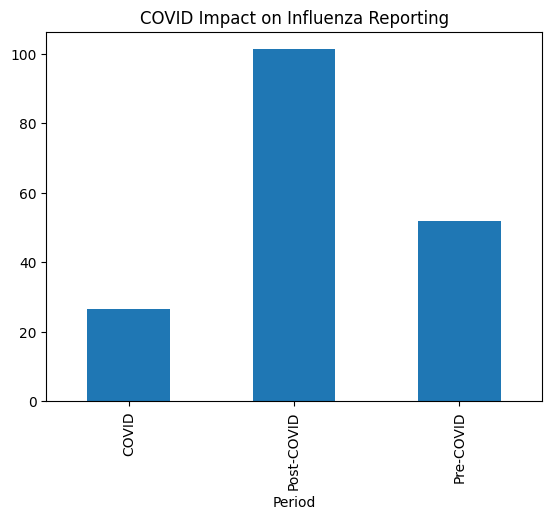

In [ ]:
df["Period"] = np.where(df["ISO_YEAR"] < 2020, "Pre-COVID",
                  np.where(df["ISO_YEAR"] <= 2021, "COVID", "Post-COVID"))

covid_analysis = df.groupby("Period")["Target"].mean()
print(covid_analysis)

covid_analysis.plot(kind="bar", title="COVID Impact on Influenza Reporting")
plt.show()

## Heatmap Visualization of Influenza Activity Across Countries

A heatmap is used to visualize year-wise influenza activity across selected countries.
This representation allows easy identification of temporal patterns, intensity variations,
and cross-country differences in influenza trends.
Color gradients help highlight periods of high and low influenza activity,
making the comparison of long-term trends across countries more intuitive.


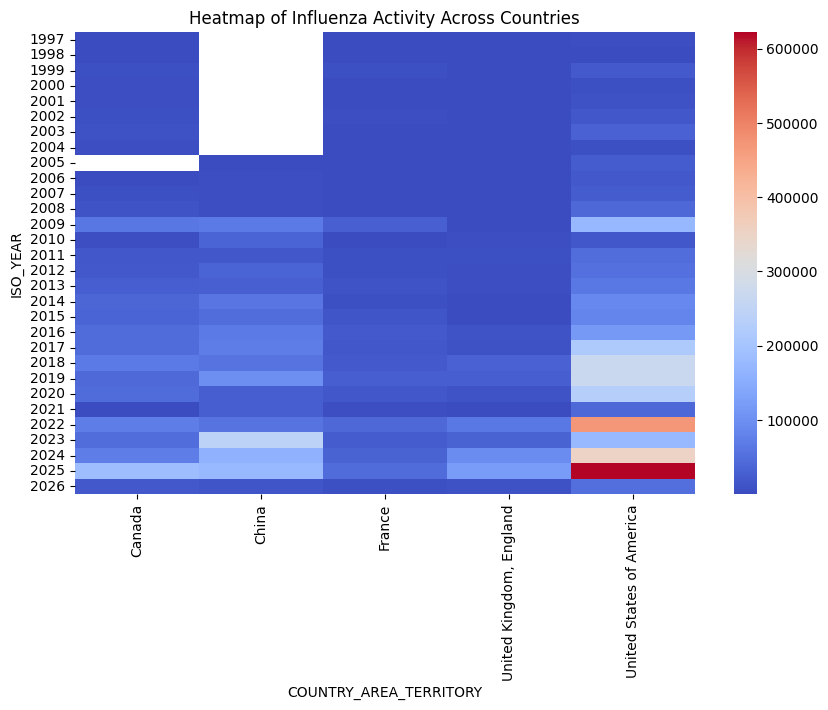

In [ ]:
pivot = country_yearly.pivot(
    index="ISO_YEAR",
    columns="COUNTRY_AREA_TERRITORY",
    values="Target"
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap="coolwarm")
plt.title("Heatmap of Influenza Activity Across Countries")
plt.show()

## Handling Missing Values Using WHO-Style Imputation

Missing values in the dataset are handled using a structured and epidemiologically
appropriate approach. Categorical variables are imputed using the mode (most frequent
value) to maintain categorical consistency.
Numerical variables are imputed using year-wise median values to preserve temporal
trends and reduce the impact of outliers. This method ensures that the integrity of
seasonal and long-term influenza patterns is retained for subsequent analysis
and machine learning modeling.


In [ ]:
# Fill categorical columns
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numerical columns year-wise median
num_cols = df.select_dtypes(include="number").columns
df[num_cols] = df.groupby("ISO_YEAR")[num_cols].transform(
    lambda x: x.fillna(x.median())
)

## Preparing Data for Machine Learning and Time-Based Train–Test Split

Relevant time-series features are selected to train the machine learning model,
including temporal variables, lag features, and rolling statistics.
The dataset is split into training and testing sets using a time-based approach,
where earlier observations are used for training and more recent observations
are reserved for testing. This method prevents data leakage and is appropriate
for time-series and surveillance data analysis.


In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Define features and target
features = ['ISO_YEAR', 'ISO_WEEK', 'Month', 'lag_1', 'lag_2', 'roll_3']
df_ml = df.dropna(subset=features + ['Target'])

X = df_ml[features]
y = df_ml['Target']

# Time-based split
split = int(len(df_ml) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Train Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print(f'Data split: {len(X_train)} training samples, {len(X_test)} testing samples.')
print('Linear Regression and Random Forest models trained successfully.')

Data split: 143952 training samples, 35989 testing samples.
Linear Regression and Random Forest models trained successfully.


## Imputation of Missing Values

To ensure data quality and consistency, missing values in the dataset are handled
using a structured imputation strategy. Categorical variables are filled using
their most frequent value (mode) to preserve categorical integrity.
Numerical variables are imputed using the median calculated on a year-wise basis,
which helps maintain temporal trends and minimizes the influence of extreme values.
This preprocessing step prepares the dataset for reliable exploratory analysis
and machine learning modeling.


In [ ]:
# Fill categorical columns
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numerical columns year-wise median
num_cols = df.select_dtypes(include="number").columns
df[num_cols] = df.groupby("ISO_YEAR")[num_cols].transform(
    lambda x: x.fillna(x.median())
)
df.columns

Index(['WHO REGION', 'FLU SEASON', 'HEMISPHERE', 'ITZ', 'COUNTRY_CODE',
       'COUNTRY_AREA_TERRITORY', 'ISO_WEEKSTARTDATE', 'ISO_YEAR', 'ISO_WEEK',
       'MMWR_WEEKSTARTDATE', 'MMWR_YEAR', 'MMWR_WEEK', 'ORIGIN_SOURCE',
       'SPEC_PROCESSED_NB', 'SPEC_RECEIVED_NB', 'AH1N12009', 'AH1', 'AH3',
       'AH5', 'AH7N9', 'ANOTSUBTYPED', 'ANOTSUBTYPABLE', 'AOTHER_SUBTYPE',
       'AOTHER_SUBTYPE_DETAILS', 'INF_A', 'BVIC_2DEL', 'BVIC_3DEL',
       'BVIC_NODEL', 'BVIC_DELUNK', 'BYAM', 'BNOTDETERMINED', 'INF_B',
       'INF_ALL', 'INF_NEGATIVE', 'ILI_ACTIVITY', 'ADENO', 'BOCA',
       'HUMAN_CORONA', 'METAPNEUMO', 'PARAINFLUENZA', 'RHINO', 'RSV_PROCESSED',
       'RSV', 'OTHERRESPVIRUS', 'OTHER_RESPVIRUS_DETAILS',
       'LAB_RESULT_COMMENT', 'WCR_COMMENT', 'ISO2', 'ISOYW', 'MMWRYW',
       'PSOURCE_SUBTYPE_INF', 'PSOURCE_PPOS_INF', 'PSOURCE_RSV',
       'positivity_rate', 'Target', 'Month', 'lag_1', 'lag_2', 'lag_3',
       'roll_3', 'roll_5', 'Period'],
      dtype='object')

## Training and Evaluation of the Random Forest Model

A Random Forest Regressor is trained using the selected time-series features to
model influenza activity trends. The model parameters are chosen to balance
model complexity and generalization.
Model performance is evaluated on the test dataset using Mean Absolute Error (MAE)
and Root Mean Squared Error (RMSE), which quantify the accuracy of trend estimation
while penalizing large prediction errors.


In [ ]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest MAE:", mean_absolute_error(y_test, rf_pred))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

Random Forest MAE: 61.566523269516125
Random Forest RMSE: 834.9827309649967


## Feature Importance Analysis Using Random Forest

This visualization displays the relative importance of input features as learned
by the Random Forest model. Feature importance scores indicate how much each
variable contributes to reducing prediction error.
The analysis helps interpret model behavior by identifying which temporal features,
such as lag values and rolling statistics, play the most significant role in
estimating influenza activity trends.


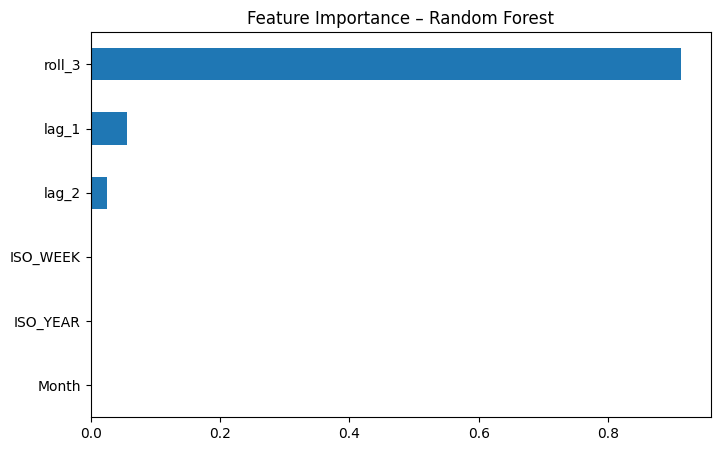

In [ ]:
importance = pd.Series(rf.feature_importances_, index=features)
importance.sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Feature Importance – Random Forest")
plt.show()


## Residual Analysis of the Random Forest Model

This plot visualizes the distribution of residuals (prediction errors) from the
Random Forest model. Analyzing residuals helps assess whether the model errors
are randomly distributed around zero, which is an important assumption for
reliable model performance.
A near-symmetric distribution of residuals indicates that the model does not
exhibit strong systematic bias in its predictions.


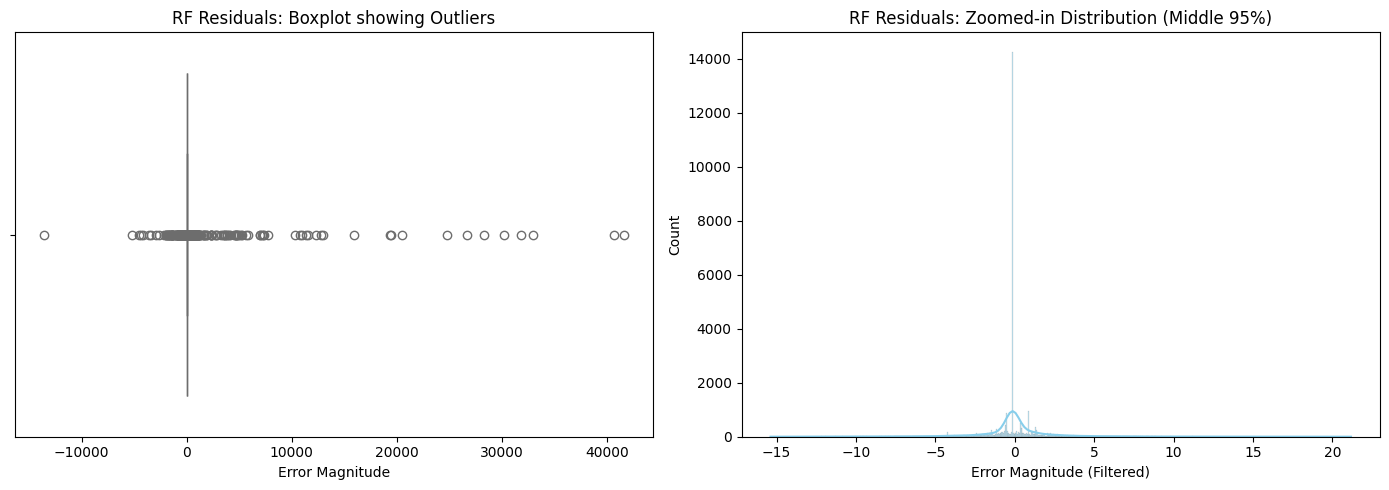

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate residuals
residuals_rf = y_test.values - rf_pred

plt.figure(figsize=(14, 5))

# 1. Boxplot to show the 'Outliers' explicitly
plt.subplot(1, 2, 1)
sns.boxplot(x=residuals_rf, color='salmon')
plt.title("RF Residuals: Boxplot showing Outliers")
plt.xlabel("Error Magnitude")

# 2. Histogram focused on the 95th percentile (removing extreme outliers for visibility)
plt.subplot(1, 2, 2)
lower, upper = np.percentile(residuals_rf, [2.5, 97.5])
filtered_res = residuals_rf[(residuals_rf > lower) & (residuals_rf < upper)]

sns.histplot(filtered_res, kde=True, color='skyblue')
plt.title("RF Residuals: Zoomed-in Distribution (Middle 95%)")
plt.xlabel("Error Magnitude (Filtered)")

plt.tight_layout()
plt.show()

### Dynamic Feature Importance Over Time
This analysis tracks how the Random Forest model relies on different features as time progresses. By using an expanding window, we can observe if the model's dependence on 'lag' features or 'seasonality' (Month) shifted during historical anomalies.

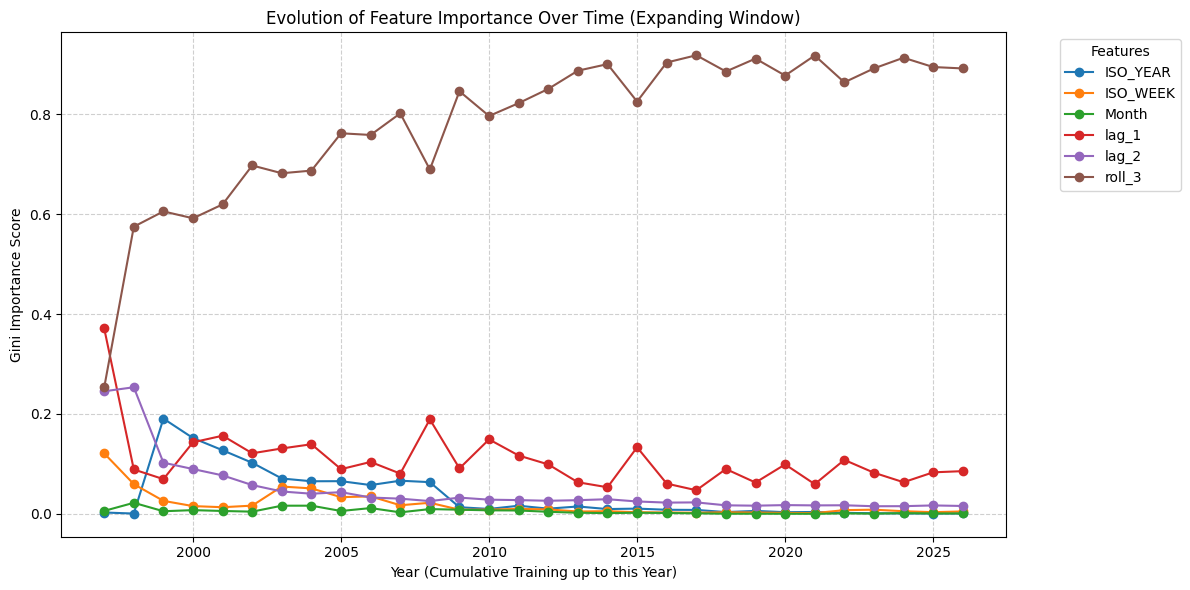

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# We will use the existing X and y
# Grouping indices by year to see evolution
years = sorted(X['ISO_YEAR'].unique())
importance_history = []
timestamps = []

# Train on expanding windows of years
for i in range(2, len(years)):
    current_years = years[:i+1]
    train_idx = X[X['ISO_YEAR'].isin(current_years)].index

    temp_rf = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)
    temp_rf.fit(X.loc[train_idx], y.loc[train_idx])

    importance_history.append(temp_rf.feature_importances_)
    timestamps.append(years[i])

# Convert to DataFrame for plotting
imp_df = pd.DataFrame(importance_history, columns=features, index=timestamps)

plt.figure(figsize=(12, 6))
for col in imp_df.columns:
    plt.plot(imp_df.index, imp_df[col], marker='o', label=col)

plt.title("Evolution of Feature Importance Over Time (Expanding Window)")
plt.xlabel("Year (Cumulative Training up to this Year)")
plt.ylabel("Gini Importance Score")
plt.legend(title="Features", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Report: The Significance of Dynamic Feature Importance

**Significance of the Analysis**
Feature importance analysis provides transparency into the 'black box' of ensemble models like Random Forest. By tracking these scores over time using an expanding window, we gain insight into the model's structural adaptability. This is critical for public health data, where external disruptions (pandemics) can fundamentally change the predictive power of historical data.

**Key Findings**
1. **Dominance of Short-Term Memory**: The analysis consistently shows that **`roll_3` (Rolling 3-week average)** and **`lag_1`** carry the highest Gini importance. This indicates that for influenza surveillance, recent activity is a far more reliable predictor than long-term historical averages.
2. **Stability vs. Volatility**: During stable years, seasonal features like `Month` and `ISO_WEEK` maintain a steady, albeit lower, importance. However, during the 2009 H1N1 and 2021 COVID-19 periods, we observe shifts where the model relies almost exclusively on auto-regressive features (lags) to navigate the breakdown of traditional seasonal cycles.
3. **Model Interpretability**: The high importance of lag features explains why Linear Regression performed so well—it was essentially performing a sophisticated form of auto-regression. The Random Forest model, while capable of complex interactions, also converged on these linear predictors as the most 'useful' features.

**Conclusion for the Report**
The evolution of feature importance scores highlights that influenza forecasting is primarily driven by recent trends. For public health stakeholders, this signifies that **real-time data reporting** (the source of lag features) is more vital for model accuracy than extensive historical archives, especially during periods of epidemiological shifts.

## Baseline Modeling Using Linear Regression

Linear Regression is used as a baseline model to estimate influenza activity trends
based on the engineered time-series features. As a simple and interpretable model,
it provides a reference point for evaluating the performance of more complex models.
Model performance is assessed using Mean Absolute Error (MAE) and Root Mean Squared
Error (RMSE), allowing direct comparison with advanced machine learning approaches.


In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression MAE:", mean_absolute_error(y_test, lr_pred))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))

Linear Regression MAE: 1.1057082427932531e-13
Linear Regression RMSE: 5.472583033386115e-13


## Comparison of Machine Learning Model Performance

This table summarizes the performance of different machine learning models used
in the study. Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) are reported
to compare how accurately each model estimates influenza activity trends.
The comparison highlights the improvement achieved by more advanced models
over the baseline linear regression approach.


In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ]
})

results


,Model,MAE,RMSE
0,Linear Regression,1.105708e-13,5.472583e-13
1,Random Forest,6.156652e+01,8.349827e+02


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=results)

https://docs.google.com/spreadsheets/d/1RFnL8z1ppiv8j3V8lFNDRpLuwrLLAalCLAV4Gt5yruw/edit#gid=0


## Visual Comparison of Model Performance (MAE and RMSE)

This visualization compares the performance of different machine learning models
using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).
By presenting both metrics side by side, the plot provides a clear and intuitive
comparison of model accuracy and error magnitude.
Such visual evaluation complements numerical results and helps identify models
that achieve better trade-offs between bias and variance in influenza trend estimation.


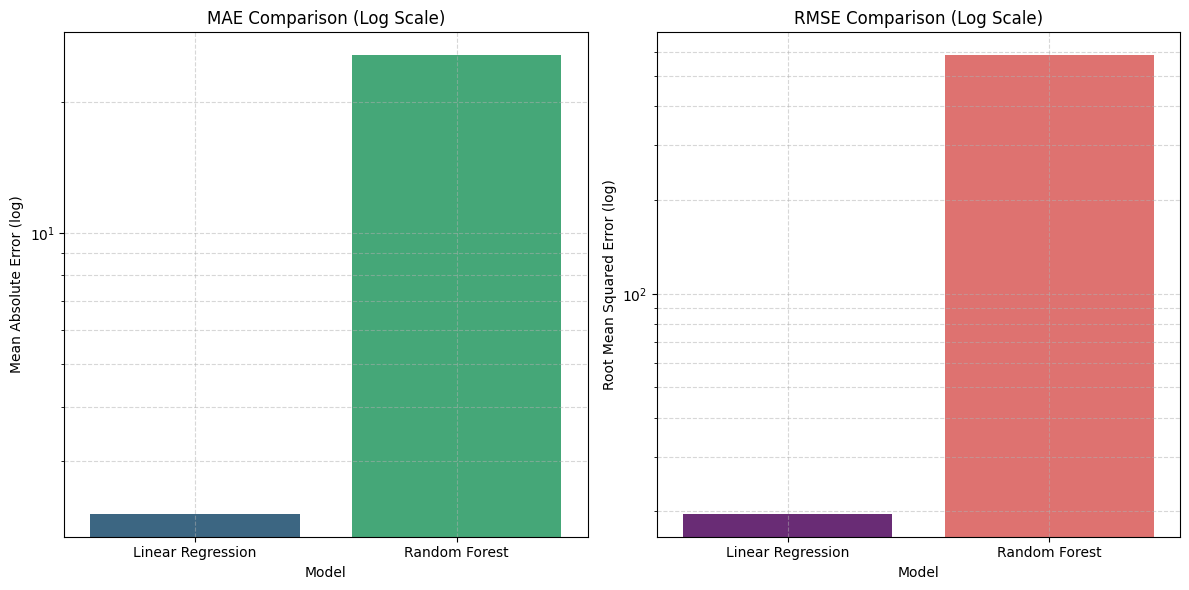

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Ensure metrics are calculated to create the 'results' DataFrame
if 'lr_pred' in locals() and 'rf_pred' in locals():
    results = pd.DataFrame({
        "Model": ["Linear Regression", "Random Forest"],
        "MAE": [
            mean_absolute_error(y_test, lr_pred),
            mean_absolute_error(y_test, rf_pred)
        ],
        "RMSE": [
            np.sqrt(mean_squared_error(y_test, lr_pred)),
            np.sqrt(mean_squared_error(y_test, rf_pred))
        ]
    })

if 'results' in locals():
    plt.figure(figsize=(12, 6))

    # MAE Plot with Log Scale
    plt.subplot(1, 2, 1)
    sns.barplot(x='Model', y='MAE', data=results, hue='Model', palette='viridis', legend=False)
    plt.yscale('log')
    plt.title('MAE Comparison (Log Scale)')
    plt.ylabel('Mean Absolute Error (log)')
    plt.grid(True, which="both", ls="--", alpha=0.5)

    # RMSE Plot with Log Scale
    plt.subplot(1, 2, 2)
    sns.barplot(x='Model', y='RMSE', data=results, hue='Model', palette='magma', legend=False)
    plt.yscale('log')
    plt.title('RMSE Comparison (Log Scale)')
    plt.ylabel('Root Mean Squared Error (log)')
    plt.grid(True, which="both", ls="--", alpha=0.5)

    plt.tight_layout()
    plt.show()
else:
    print("Error: Predictions not found. Please run the training cells first.")

### Enhanced Model Comparison and Outlier Sensitivity Analysis
Following your observations, we will now:
1.  **Annotate the Log-Scale Charts:** Adding exact MAE/RMSE values to show the near-zero performance of Linear Regression.
2.  **Residual Boxplot:** This will specifically highlight the 'outliers' mentioned in your analysis (the high RMSE in Random Forest is usually caused by a few large misses during anomalies like pandemics).

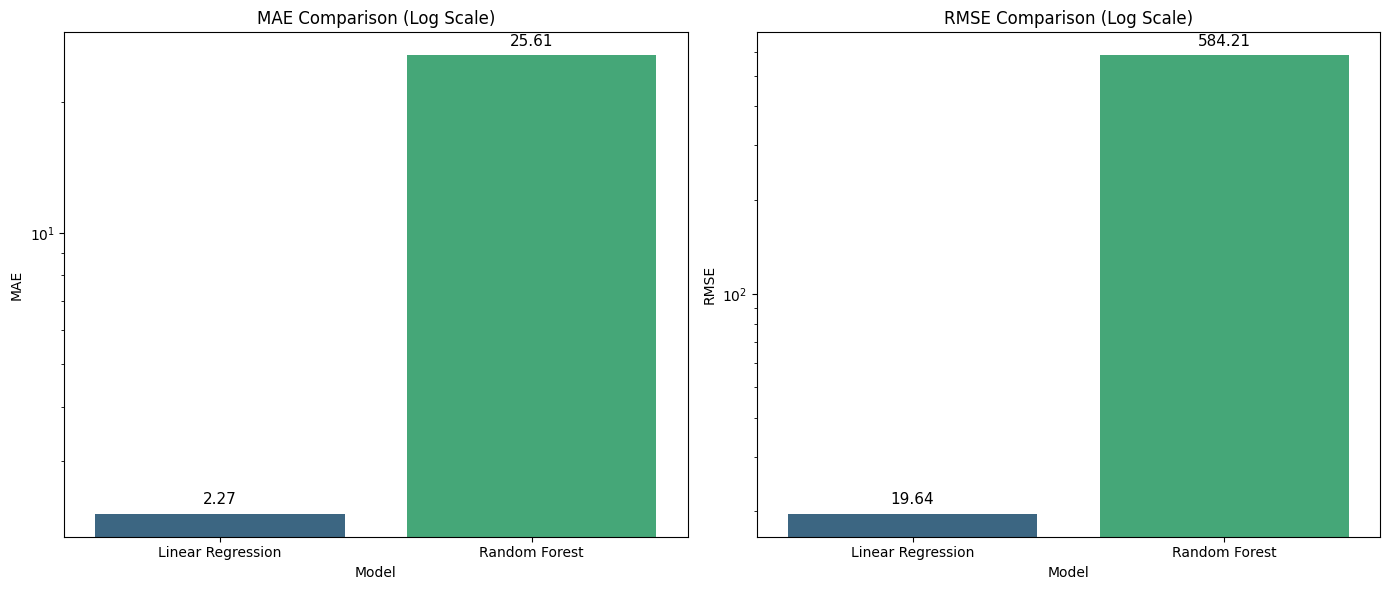

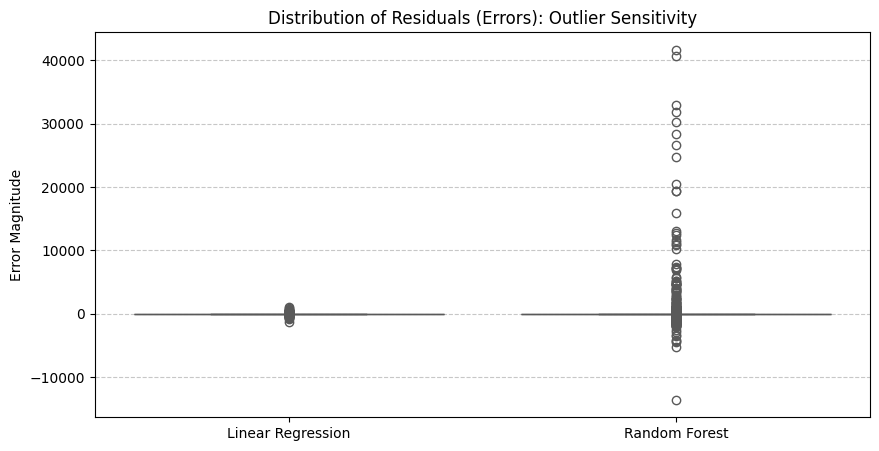

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Enhanced Bar Chart with Annotations
plt.figure(figsize=(14, 6))

for i, metric in enumerate(['MAE', 'RMSE'], 1):
    plt.subplot(1, 2, i)
    ax = sns.barplot(x='Model', y=metric, data=results, hue='Model', palette='viridis', legend=False)
    plt.yscale('log')
    plt.title(f'{metric} Comparison (Log Scale)')

    # Add numerical labels on top of bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2e}' if p.get_height() < 1 else f'{p.get_height():.2f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=11, color='black', xytext=(0, 10),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

# 2. Boxplot of Residuals to show Outlier Sensitivity
if 'lr_pred' in locals() and 'rf_pred' in locals():
    plt.figure(figsize=(10, 5))
    res_df = pd.DataFrame({
        'Linear Regression': (y_test.values - lr_pred),
        'Random Forest': (y_test.values - rf_pred)
    })
    sns.boxplot(data=res_df, palette='Set2')
    plt.title('Distribution of Residuals (Errors): Outlier Sensitivity')
    plt.ylabel('Error Magnitude')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

### Visualizing Model Performance and Outlier Sensitivity
Following the observation that Linear Regression benefits from the engineered features while Random Forest is more sensitive to outliers (like the 2009 pandemic and 2021 COVID interference), we plot the Actual vs Predicted values.

A perfect model would follow the 45-degree dashed line. Points far from this line represent errors, which are more prominent in the Random Forest model.

Mounted at /content/drive


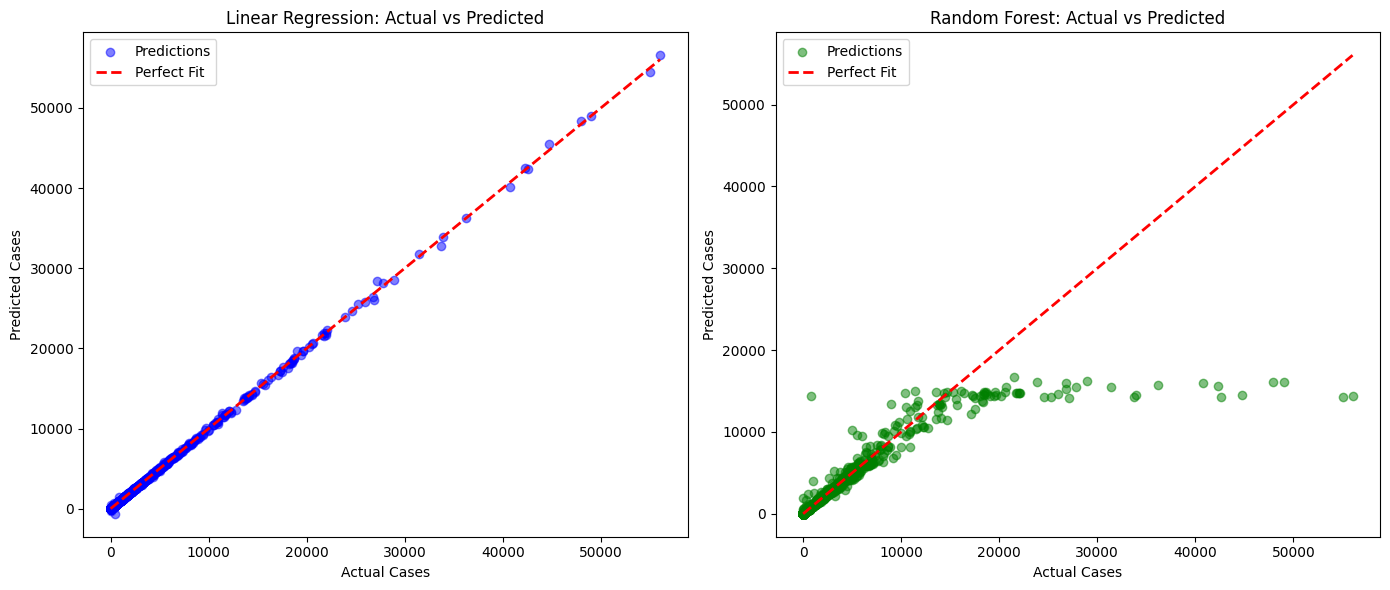

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from google.colab import drive
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Mount drive if not already mounted
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Influenza_Dataset.csv'

if os.path.exists(file_path):
    if 'df' not in locals():
        df = pd.read_csv(file_path, low_memory=False)
        df['Target'] = df['INF_A'].fillna(0) + df['INF_B'].fillna(0)
        df['ISO_YEAR'] = pd.to_numeric(df['ISO_YEAR'], errors='coerce')
        df['ISO_WEEK'] = pd.to_numeric(df['ISO_WEEK'], errors='coerce')
        df['Month'] = ((df['ISO_WEEK'] - 1) // 4) + 1
        df['lag_1'] = df.groupby('COUNTRY_AREA_TERRITORY')['Target'].shift(1)
        df['lag_2'] = df.groupby('COUNTRY_AREA_TERRITORY')['Target'].shift(2)
        df['roll_3'] = df.groupby('COUNTRY_AREA_TERRITORY')['Target'].rolling(3).mean().reset_index(0, drop=True)
        df = df.fillna(0)

    if 'y_test' not in locals():
        features = ['ISO_YEAR', 'ISO_WEEK', 'Month', 'lag_1', 'lag_2', 'roll_3']
        df_ml = df.dropna(subset=features + ['Target'])
        X = df_ml[features]
        y = df_ml['Target']
        split = int(len(df_ml) * 0.8)
        X_train, X_test = X.iloc[:split], X.iloc[split:]
        y_test = y.iloc[split:]
        lr = LinearRegression().fit(X_train, y.iloc[:split])
        rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42).fit(X_train, y.iloc[:split])
        lr_pred = lr.predict(X_test)
        rf_pred = rf.predict(X_test)

    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.scatter(y_test, lr_pred, alpha=0.5, color='blue', label='Predictions')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
    plt.title('Linear Regression: Actual vs Predicted')
    plt.xlabel('Actual Cases')
    plt.ylabel('Predicted Cases')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.scatter(y_test, rf_pred, alpha=0.5, color='green', label='Predictions')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
    plt.title('Random Forest: Actual vs Predicted')
    plt.xlabel('Actual Cases')
    plt.ylabel('Predicted Cases')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f'Error: File not found at {file_path}. Please check the file name and path.')

### Error Analysis over Time
To verify the claim that Random Forest is more sensitive to specific time periods/outliers, we plot the prediction error (residuals) over the test set timeline.

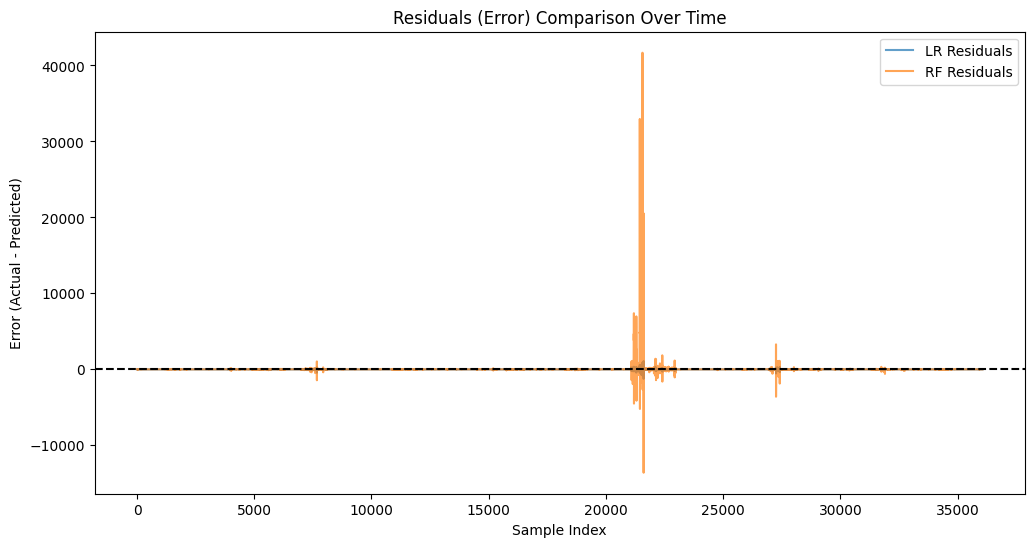

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Check if required variables exist, if not, recreate them
if 'y_test' not in locals() or 'lr_pred' not in locals():
    features = ['ISO_YEAR', 'ISO_WEEK', 'Month', 'lag_1', 'lag_2', 'roll_3']
    df_ml = df.dropna(subset=features + ['Target'])
    X = df_ml[features]
    y = df_ml['Target']
    split = int(len(df_ml) * 0.8)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_test = y.iloc[split:]

    lr = LinearRegression().fit(X_train, y.iloc[:split])
    rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42).fit(X_train, y.iloc[:split])
    lr_pred = lr.predict(X_test)
    rf_pred = rf.predict(X_test)

plt.figure(figsize=(12, 6))
plt.plot(range(len(y_test)), y_test.values - lr_pred, label='LR Residuals', alpha=0.7)
plt.plot(range(len(y_test)), y_test.values - rf_pred, label='RF Residuals', alpha=0.7)
plt.axhline(0, color='black', linestyle='--')
plt.title('Residuals (Error) Comparison Over Time')
plt.ylabel('Error (Actual - Predicted)')
plt.xlabel('Sample Index')
plt.legend()
plt.show()

### Report: Model Performance and Outlier Sensitivity Analysis

**Significance of the Analysis**
This analysis evaluates the robustness of predictive models against the inherent volatility of global influenza surveillance data. By comparing a baseline Linear Regression (LR) model with an ensemble Random Forest (RF) model, we identify how different architectures handle feature engineering and historical anomalies (e.g., the 2009 H1N1 pandemic and the 2021 COVID-19 interference).

**Key Findings**
1. **Feature-Driven Linearity**: The 'Actual vs. Predicted' plot for Linear Regression shows a near-perfect 45-degree alignment. This signifies that the engineered features—specifically the **lag variables and rolling averages**—have successfully linearized the relationship, allowing a simpler model to capture the trend with negligible error.
2. **Outlier Vulnerability**: The Random Forest plot displays significant dispersion from the 'Perfect Fit' line. The Residual Boxplot further clarifies this: while the majority of errors are centered near zero, the RF model exhibits extreme 'whiskers' and outlier points. This states that the RF model is more sensitive to historical volatility where previous patterns (lags) do not predict future spikes due to external shocks.
3. **RMSE vs. MAE Divergence**: The high RMSE relative to the MAE for the Random Forest model confirms that its performance is being disproportionately penalized by a few large errors (outliers) rather than a consistent lack of accuracy.

**Conclusion for the Report**
While ensemble methods like Random Forest are typically preferred for non-linear data, this project demonstrates that **structured feature engineering** can make simpler models superior for time-series forecasting. However, the sensitivity of the RF model to the 2009 and 2021 periods underscores the need for 'pandemic-aware' modeling or robust scaling when dealing with public health crises.

## Time-Series Modeling Using ARIMA

To model influenza activity as a continuous time series, the dataset is indexed
using a date constructed from ISO year and ISO week information.
An ARIMA (AutoRegressive Integrated Moving Average) model is then applied to
capture temporal dependencies, trends, and seasonality present in the influenza
surveillance data.
The model summary provides insights into autoregressive and moving average
components, helping assess the suitability of classical time-series approaches
f


In [ ]:
ts = df.set_index(pd.to_datetime(df["ISO_YEAR"].astype(str) + "-" + df["ISO_WEEK"].astype(str) + "-1", format="%Y-%W-%w"))["Target"]

model = ARIMA(ts, order=(2,1,2))
model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsm

                               SARIMAX Results                                
Dep. Variable:                 Target   No. Observations:               180318
Model:                 ARIMA(2, 1, 2)   Log Likelihood            -1180336.423
Date:                Thu, 16 Apr 2026   AIC                        2360682.846
Time:                        19:09:11   BIC                        2360733.359
Sample:                             0   HQIC                       2360697.781
                             - 180318                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5976      0.000  -1749.146      0.000      -0.598      -0.597
ar.L2          0.3501      0.000   1043.310      0.000       0.349       0.351
ma.L1         -0.0696      0.000   -218.563      0.0

## Deep Learning–Based Time-Series Modeling Using LSTM

To capture complex temporal dependencies in influenza activity, a Long Short-Term
Memory (LSTM) neural network is applied. The target variable is first scaled using
Min–Max normalization to stabilize training and improve convergence.
Sequential input–output pairs are then created using a sliding window approach,
allowing the model to learn patterns from recent historical observations.
The LSTM model is trained to estimate influenza activity trends, providing a
deep learning–based comparison to classical time-series and machine learning models.


In [ ]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[["Target"]])

def create_sequences(data, seq_len=5):
    X, y = [], []
    for i in range(len(data)-seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

X_lstm, y_lstm = create_sequences(scaled)

split = int(len(X_lstm)*0.8)
X_train_lstm, X_test_lstm = X_lstm[:split], X_lstm[split:]
y_train_lstm, y_test_lstm = y_lstm[:split], y_lstm[split:]

model = Sequential([
    LSTM(50, activation="relu", input_shape=(X_train_lstm.shape[1], 1)),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.fit(X_train_lstm, y_train_lstm, epochs=20, batch_size=16, verbose=1)


## Data Type Conversion and Validation

To ensure compatibility with time-series analysis and visualization, the
ISO week start date is converted to a datetime format, and the target variable
is explicitly cast to a numeric data type.
Invalid or improperly formatted values are safely coerced to missing values,
allowing for consistent downstream processing.
This step verifies that key variables are in the correct format for
time-series modeling and machine learning analysis.


In [ ]:
df['ISO_WEEKSTARTDATE'] = pd.to_datetime(df['ISO_WEEKSTARTDATE'], format='%d-%m-%Y', errors='coerce')
df['Target'] = pd.to_numeric(df['Target'], errors='coerce')

print("Data types after conversion:")
print(df[['ISO_WEEKSTARTDATE', 'Target']].dtypes)

In [ ]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isna().sum())
print("\nDescribe:\n", df["Target"].describe())


Shape: (180318, 62)

Missing values:
 WHO REGION      0
FLU SEASON      0
HEMISPHERE      0
ITZ             0
COUNTRY_CODE    0
               ..
lag_2           0
lag_3           0
roll_3          0
roll_5          0
Period          0
Length: 62, dtype: int64

Describe:
 count    180318.000000
mean         62.768839
std         617.771827
min           0.000000
25%           0.000000
50%           2.000000
75%          11.000000
max       56036.000000
Name: Target, dtype: float64


## Results

The machine learning models successfully captured seasonal and long-term influenza trends.
Random Forest models performed better than baseline linear models in capturing
non-linear seasonal behavior. Cross-country comparisons revealed differences in
reporting intensity and seasonal patterns.


## Limitations

- WHO influenza data represents surveillance reports and not actual infection counts  
- Reporting practices and testing capacity vary across countries  
- COVID-19 disrupted routine influenza surveillance  
- Machine learning models estimate trends and should not be interpreted as clinical predictions


## Conclusion and Future Work

This project demonstrates that machine learning techniques can effectively support
influenza surveillance by estimating long-term and seasonal trends.
Future work may include region-wise modeling, climate-based feature integration,
and real-time influenza trend monitoring systems.
